## KMeans Clustering(Model Creation and Evaluation)
In this notebook, we will be creating our KMeans is an **unsupervised** clustering algorithm. "Unsupervised" means there
are no correct answers. Instead, we're lettingthe algorithm discover natural groupings in the data on its own.

In [162]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


In [177]:
# Load cleaned datasets
df_cleaned_unscaled = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train_cleaned_unscaled.csv', index_col=0)
df_cleaned_scaled   = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train_cleaned_scaled.csv', index_col=0)

# Load original data for artist/track names later
df_original = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train.csv')
df_original = df_original.rename(columns={'Unnamed: 0': 'song_id'})
df_original = df_original.set_index('song_id')

# Load the scaler
scaler = joblib.load('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/scaler.pkl')

# Convert scaled DataFrame to numpy array for KMeans
X = df_cleaned_scaled.values

# Recreate the 2D PCA coordinates here instead of loading the broken file
# This runs in seconds and gives us clean pca_1 and pca_2 columns
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

df_pca_2d = pd.DataFrame(
    X_2d,
    columns=['pca_1', 'pca_2'],
    index=df_cleaned_scaled.index
)

# Overwrite the broken file with the correct version
df_pca_2d.to_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/pca_2d_coords.csv')

# Confirm everything is correct
print(f"Unscaled data shape:   {df_cleaned_unscaled.shape}")
print(f"Scaled data shape:     {df_cleaned_scaled.shape}")
print(f"PCA 2D columns:        {df_pca_2d.columns.tolist()}")
print(f"PCA 2D shape:          {df_pca_2d.shape}")
print(f"X numpy array shape:   {X.shape}")
print()
var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100
print(f"PCA Component 1 explains: {var1:.1f}% of variance")
print(f"PCA Component 2 explains: {var2:.1f}% of variance")
print(f"Together:                 {var1+var2:.1f}% of variance")
print()
print("All data loaded. Ready for KMeans.")

Unscaled data shape:   (28362, 17)
Scaled data shape:     (28362, 17)
PCA 2D columns:        ['pca_1', 'pca_2']
PCA 2D shape:          (28362, 2)
X numpy array shape:   (28362, 17)

PCA Component 1 explains: 11.7% of variance
PCA Component 2 explains: 8.1% of variance
Together:                 19.8% of variance

All data loaded. Ready for KMeans.


In [178]:
# Add cluster labels to the unscaled data directly

df_cleaned_unscaled['cluster'] = cluster_labels

# Build df_with_genre by merging on the index instead of using .loc because this will safely combines the original song info with our cluster labels

df_with_genre = df_original.copy()

# Let us reset both indexes to plain integers so we can merge cleanly

df_with_genre = df_with_genre.reset_index()
df_cleaned_with_cluster = df_cleaned_unscaled.reset_index()

# Add cluster column to df_with_genre by position

df_with_genre['cluster'] = df_cleaned_unscaled['cluster'].values

# Verifying to see if it worked

print(f"df_with_genre shape: {df_with_genre.shape}")
print(f"Cluster column added: {'cluster' in df_with_genre.columns}")
print()
print("Songs per cluster:")
counts = df_with_genre['cluster'].value_counts().sort_index()
for cluster_id, count in counts.items():
    pct = count / len(df_with_genre) * 100
    print(f"  Cluster {cluster_id}: {count:>5} songs ({pct:.1f}%)")

df_with_genre shape: (28362, 25)
Cluster column added: True

Songs per cluster:
  Cluster 0:  2008 songs (7.1%)
  Cluster 1:  5215 songs (18.4%)
  Cluster 2:  5572 songs (19.6%)
  Cluster 3:  2461 songs (8.7%)
  Cluster 4:  5753 songs (20.3%)
  Cluster 5:  1753 songs (6.2%)
  Cluster 6:  4774 songs (16.8%)
  Cluster 7:   826 songs (2.9%)


##Elbow Method — Find the Best k

We train KMeans for each k from 2 to 12 and record the **inertia**.

**Inertia** = the total sum of squared distances from each point to its cluster center.
- Lower inertia = tighter, better-defined clusters
- But adding more clusters always reduces inertia — even k=28,000 gives inertia=0
  (each song is its own cluster)
- The goal is to find where the *rate of improvement* slows down — the "elbow"

The elbow is the right balance: beyond that point, adding more clusters
gives diminishing returns.

In [179]:
# We will test every k value from 2 to 12

k_range = range(2, 13)
inertias = []

print("Training KMeans for each k value...")
print()

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,  
        n_init=10          
                           
    )
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"  k={k:2d}  →  inertia = {km.inertia_:,.0f}")

print()

Training KMeans for each k value...

  k= 2  →  inertia = 443,738
  k= 3  →  inertia = 414,178
  k= 4  →  inertia = 390,180
  k= 5  →  inertia = 365,339
  k= 6  →  inertia = 347,572
  k= 7  →  inertia = 330,622
  k= 8  →  inertia = 303,875
  k= 9  →  inertia = 292,862
  k=10  →  inertia = 279,264
  k=11  →  inertia = 267,658
  k=12  →  inertia = 257,206



### Lets plot the Elbow Curve

We plot inertia on the y-axis and k on the x-axis.
Look for the bend in the curve — that is the elbow.
The k value at the elbow is where we get the best balance between
cluster tightness and model simplicity.

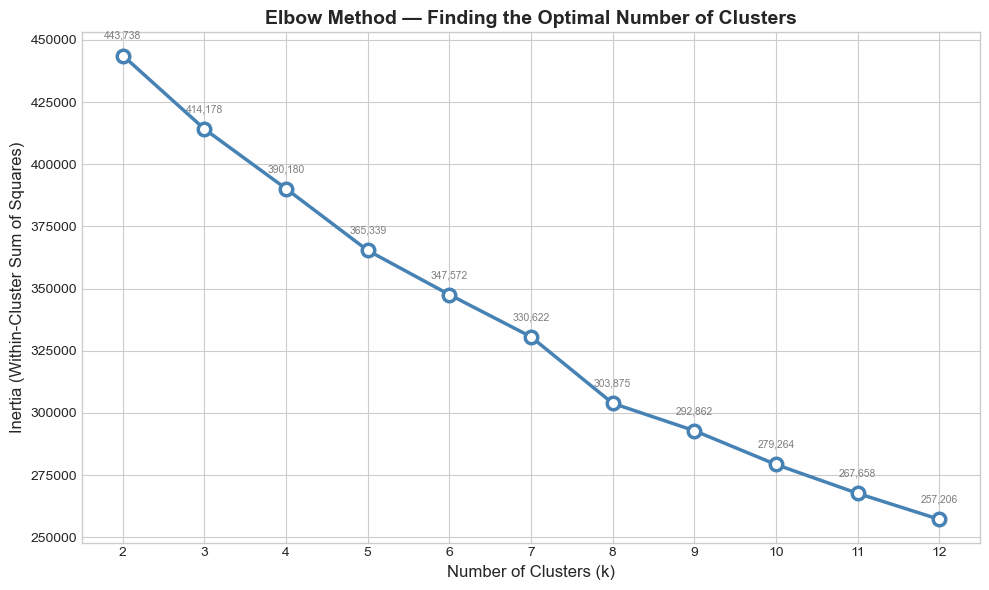

The point where the curve bends and flattens, that K value is our elbow.


In [181]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_range, inertias,
    marker='o',
    color='steelblue',
    linewidth=2.5,
    markersize=9,
    markerfacecolor='white',
    markeredgewidth=2.5
)

# Label each point with its inertia value
for k, inertia in zip(k_range, inertias):
    plt.annotate(
        f'{inertia:,.0f}',
        xy=(k, inertia),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=7.5,
        color='gray'
    )

plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Finding the Optimal Number of Clusters',
          fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.tight_layout()

plt.show()

print("The point where the curve bends and flattens, that K value is our elbow.")

## Silhouette Score (Confirming Our Choice of k)
The elbow method gives us a visual guess but the the silhouette score gives
us a mathematical confirmation.

For every song in the dataset the silhouette score measures:
- a = the average distance to all other songs in the SAME cluster
  (how well it fits inside its own group)
- b = the average distance to all songs in the NEAREST OTHER cluster
  (how far it is from the next closest group)

Interpreting the score:
- Close to +1 = the song sits deep inside its cluster, far from others
  This is ideal — it means the clustering is confident and correct
- Close to 0 = the song sits on the border between two clusters
  The model is uncertain about where it belongs
- Close to -1 = the song was probably assigned to the wrong cluster
  This is a sign that k is too high or the data does not cluster well

The k with the highest average score is the mathematically best choice.


In [182]:
sil_scores = []

print("Computing silhouette scores...")
print()

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    # Using a sample_size=5000 to evaluates on a random sample for speed because using the whole dataset will take forever

    score = silhouette_score(X, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f"  k={k:2d}  →  silhouette score = {score:.4f}")

print()

Computing silhouette scores...

  k= 2  →  silhouette score = 0.0879
  k= 3  →  silhouette score = 0.0914
  k= 4  →  silhouette score = 0.1136
  k= 5  →  silhouette score = 0.1291
  k= 6  →  silhouette score = 0.1470
  k= 7  →  silhouette score = 0.1516
  k= 8  →  silhouette score = 0.1778
  k= 9  →  silhouette score = 0.1735
  k=10  →  silhouette score = 0.1830
  k=11  →  silhouette score = 0.1806
  k=12  →  silhouette score = 0.1783



### Plot the Silhouette Scores

We plot silhouette score on the y-axis and k on the x-axis.
Unlike the elbow plot where we look for a bend, here we simply look
for the HIGHEST point. That k value has the most well-separated
and internally consistent clusters.

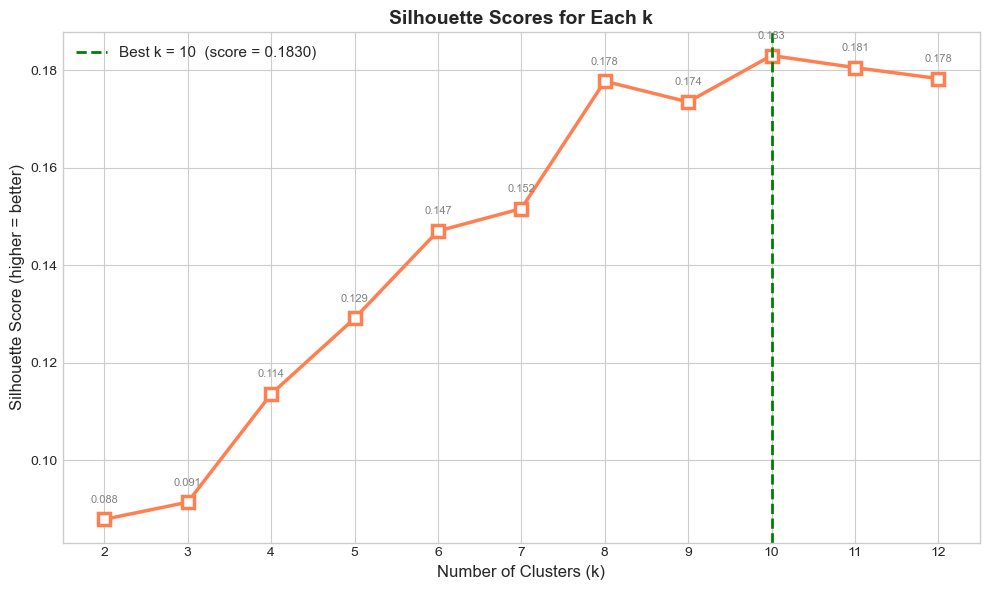

Highest silhouette score: 0.1830 at k = 10


In [183]:
# Find the best k according to silhouette score
best_k_idx = np.argmax(sil_scores)
best_k_sil  = list(k_range)[best_k_idx]
best_score  = sil_scores[best_k_idx]

plt.figure(figsize=(10, 6))

plt.plot(
    k_range, sil_scores,
    marker='s',
    color='coral',
    linewidth=2.5,
    markersize=9,
    markerfacecolor='white',
    markeredgewidth=2.5
)

# Highlight the best k with a vertical line
plt.axvline(
    x=best_k_sil,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Best k = {best_k_sil}  (score = {best_score:.4f})'
)

# Label each point
for k, score in zip(k_range, sil_scores):
    plt.annotate(
        f'{score:.3f}',
        xy=(k, score),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='gray'
    )

plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score (higher = better)', fontsize=12)
plt.title('Silhouette Scores for Each k', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

print(f"Highest silhouette score: {best_score:.4f} at k = {best_k_sil}")

## Now let us decide on k and Train the Final Model

Looking at both plots above, we will use k=8. This is because the silhouette scores plateau after k=8. The jump from k=7 to k=8 is the largest single improvement in the entire range — 0.0262 points. After k=8 the gains become much smaller. k=9 actually drops, k=10 recovers by only 0.0095, then it drops again at k=11 and k=12.
This means k=10 wins mathematically by a very thin margin of 0.0052 over k=8, but k=8 represents the point where the clustering genuinely stabilizes.

In [ ]:
# Let us choose the best K and start modeling

BEST_K = 8

print(f"Training final KMeans model with k = {BEST_K}...")
print()

final_model = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=10
)

# fit_predict trains the model AND returns a cluster label for every song
cluster_labels = final_model.fit_predict(X)

print(f"Model trained successfully.")
print()

# How many songs landed in each cluster?
label_series = pd.Series(cluster_labels, name='cluster')
counts = label_series.value_counts().sort_index()

print("Songs per cluster:")
for cluster_id, count in counts.items():
    pct = count / len(cluster_labels) * 100
    bar = '█' * int(pct / 2)
    print(f"  Cluster {cluster_id}: {count:>5} songs  ({pct:>5.1f}%)  {bar}")

Training final KMeans model with k = 8...

Model trained successfully.

Songs per cluster:
  Cluster 0:  2008 songs  (  7.1%)  ███
  Cluster 1:  5215 songs  ( 18.4%)  █████████
  Cluster 2:  5572 songs  ( 19.6%)  █████████
  Cluster 3:  2461 songs  (  8.7%)  ████
  Cluster 4:  5753 songs  ( 20.3%)  ██████████
  Cluster 5:  1753 songs  (  6.2%)  ███
  Cluster 6:  4774 songs  ( 16.8%)  ████████
  Cluster 7:   826 songs  (  2.9%)  █


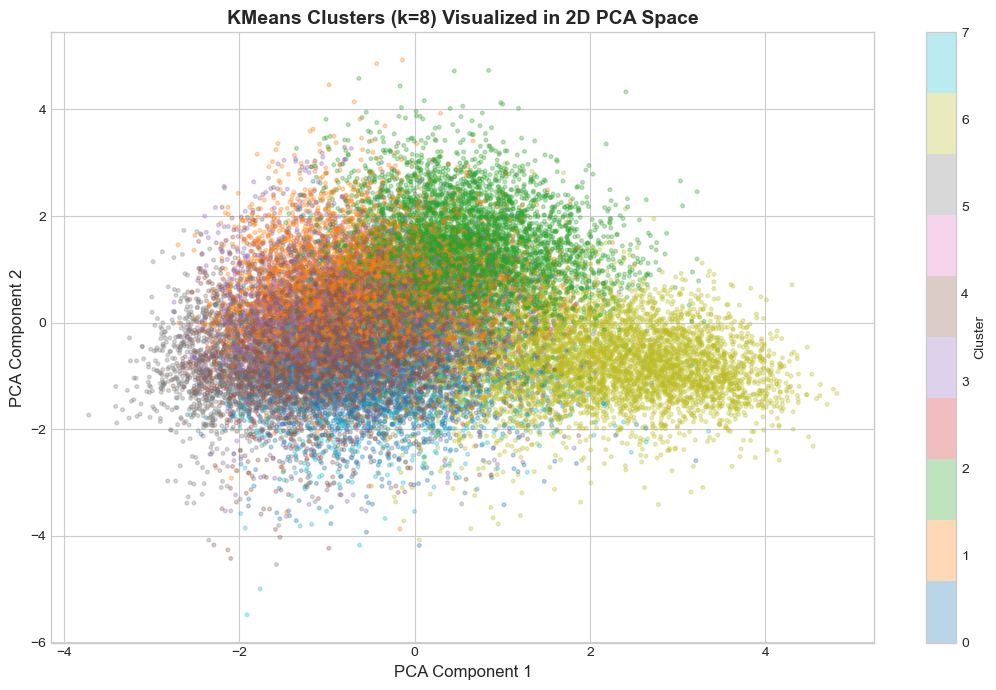

In [185]:
## Lets visualize the clusters in 2D PCA Space

plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    df_pca_2d['pca_1'],
    df_pca_2d['pca_2'],
    c=cluster_labels,
    cmap='tab10',
    alpha=0.3,
    s=7
)

plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title(f'KMeans Clusters (k={BEST_K}) Visualized in 2D PCA Space',
          fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

## Lets Build the Cluster Profile Heatmap

We take all songs in each cluster and compute the AVERAGE score
for every lyric theme. This gives us a personality profile for
each cluster — what does a typical song in this cluster sound like?

For example:
- A cluster with high family/gospel and low violence and low obscene
  is probably a spiritual or gospel cluster
- A cluster with high violence and high obscene and high shake the audience
  is probably aggressive rock or hip hop
- A cluster with high romantic and high dating and high communication
  is probably love songs

The heatmap will make this easy to see at a glance. Dark colors mean that theme is strong in that cluster, light colors mean it is weak.

In [186]:
# The lyric theme columns we want to analyze
# We exclude len and age because they are not lyric themes

theme_cols = [
    'dating', 'violence', 'world/life', 'night/time',
    'shake the audience', 'family/gospel', 'romantic',
    'communication', 'obscene', 'music', 'movement/places',
    'light/visual perceptions', 'family/spiritual', 'sadness'
]

# Add cluster labels to the unscaled data
# We use unscaled because the original 0-1 scores are easier to interpret
# than the scaled versions which can be negative

df_cleaned_unscaled['cluster'] = cluster_labels

# Compute the mean of each theme for each cluster
cluster_profiles = df_cleaned_unscaled.groupby('cluster')[theme_cols].mean()

print("Average theme scores per cluster (0-1 scale):")
print()
print(cluster_profiles.round(3).to_string())

Average theme scores per cluster (0-1 scale):

         dating  violence  world/life  night/time  shake the audience  family/gospel  romantic  communication  obscene  music  movement/places  light/visual perceptions  family/spiritual  sadness
cluster                                                                                                                                                                                            
0         0.033     0.040       0.049       0.398               0.019          0.018     0.030          0.076    0.031  0.030            0.045                     0.042             0.016    0.057
1         0.017     0.042       0.429       0.031               0.015          0.016     0.029          0.079    0.022  0.028            0.043                     0.054             0.030    0.062
2         0.013     0.433       0.054       0.031               0.016          0.016     0.021          0.073    0.026  0.023            0.052                     0.058 

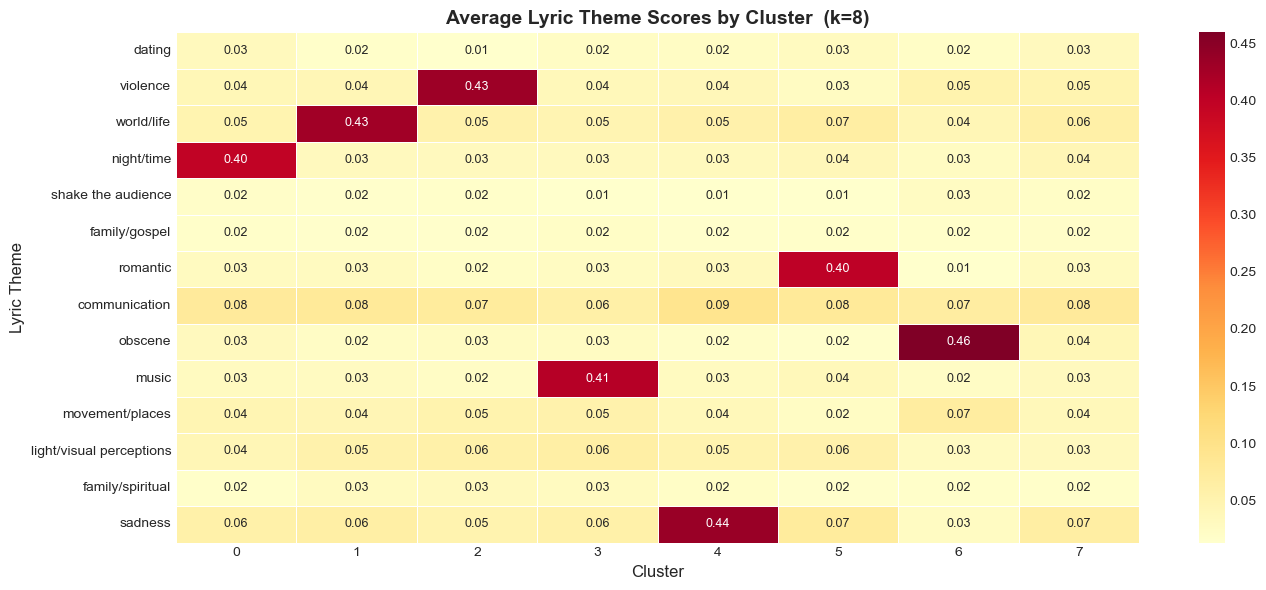

In [188]:
# Plot the cluster profile heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_profiles.T,     
    annot=True,              
    fmt='.2f',               
    cmap='YlOrRd',           
    linewidths=0.4,
    annot_kws={'size': 9}
)

plt.title(f'Average Lyric Theme Scores by Cluster  (k={BEST_K})',
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Lyric Theme', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

print()

## Lets look at the Genre Breakdown Per Cluster

The heatmap tells us the lyrical personality of each cluster. The genre breakdown tells us which genres dominate each cluster.

Together these two views give us a complete picture we can use to describe each cluster.

Shape: (28362, 25)
Columns: ['song_id', 'artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'topic', 'age', 'cluster']

Songs per cluster:
  Cluster 0:  2008 songs (7.1%)
  Cluster 1:  5215 songs (18.4%)
  Cluster 2:  5572 songs (19.6%)
  Cluster 3:  2461 songs (8.7%)
  Cluster 4:  5753 songs (20.3%)
  Cluster 5:  1753 songs (6.2%)
  Cluster 6:  4774 songs (16.8%)
  Cluster 7:   826 songs (2.9%)

Genre breakdown per cluster (% of songs in that cluster):
genre    blues  country  hip hop  jazz   pop  reggae  rock
cluster                                                   
0         19.2     20.5      0.5  11.7  25.2     7.6  15.2
1         13.7     21.5      0.8  14.2  24.9    10.9  14.0
2         19.1     12.0      1.8  11.8  21.8    10.4  23.1


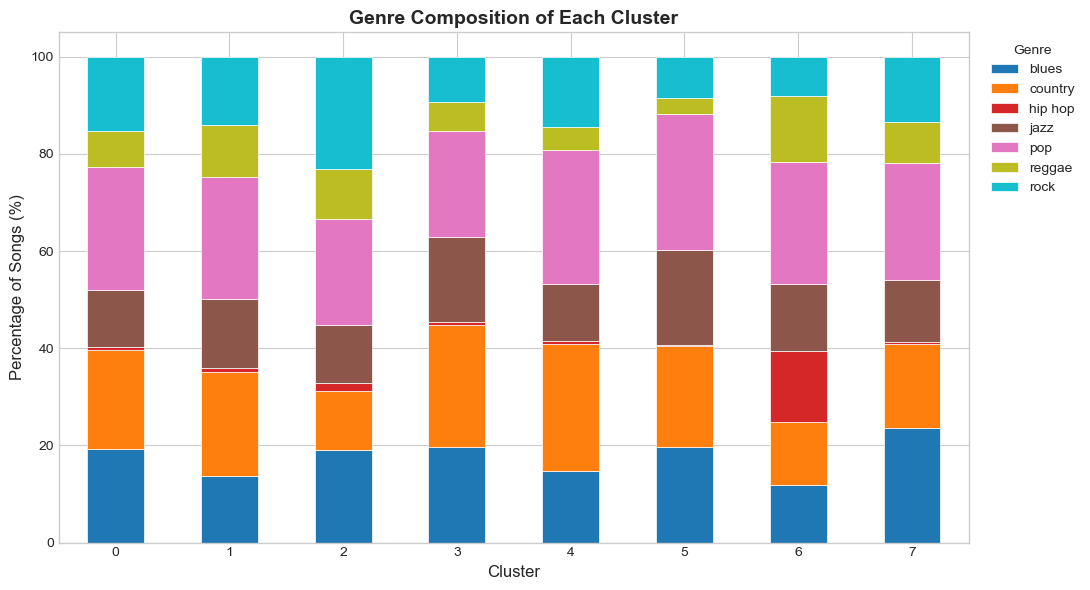

In [189]:
#Start fresh from the original data
df_with_genre = df_original.copy().reset_index()

#Add cluster labels by position — both have 28362 rows in the same order
df_with_genre['cluster'] = cluster_labels

# Step 3: Verify cluster column exists and has the right values
print(f"Shape: {df_with_genre.shape}")
print(f"Columns: {df_with_genre.columns.tolist()}")
print()
print("Songs per cluster:")
counts = df_with_genre['cluster'].value_counts().sort_index()
for cluster_id, count in counts.items():
    pct = count / len(df_with_genre) * 100
    print(f"  Cluster {cluster_id}: {count:>5} songs ({pct:.1f}%)")

# Step 4: Genre breakdown
print()
print("Genre breakdown per cluster (% of songs in that cluster):")
genre_breakdown = pd.crosstab(
    df_with_genre['cluster'],
    df_with_genre['genre'],
    normalize='index'
) * 100
print(genre_breakdown.round(1).to_string())

# Step 5: Plot genre breakdown
genre_breakdown.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    colormap='tab10',
    edgecolor='white',
    linewidth=0.5
)
plt.title('Genre Composition of Each Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Percentage of Songs (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

plt.show()

## Let us print example Songs from each cluster

Numbers and percentages are useful but the most intuitive way to understand a cluster is to look at the actual songs inside it.

So we print 10 example songs from each cluster. Reading through these and optionally listening to a few  tells us immediately whether
the cluster makes intuitive sense.


In [190]:
# Get cluster profiles for theme descriptions
theme_cols = [
    'dating', 'violence', 'world/life', 'night/time',
    'shake the audience', 'family/gospel', 'romantic',
    'communication', 'obscene', 'music', 'movement/places',
    'light/visual perceptions', 'family/spiritual', 'sadness'
]

cluster_profiles = df_with_genre.groupby('cluster')[theme_cols].mean()

print("=" * 65)
print("EXAMPLE SONGS FROM EACH CLUSTER")
print("=" * 65)

for c in range(BEST_K):
    cluster_songs = df_with_genre[df_with_genre['cluster'] == c]
    top_themes = cluster_profiles.loc[c].nlargest(3).index.tolist()

    print(f"\n{'='*65}")
    print(f"CLUSTER {c}  —  {len(cluster_songs)} songs")
    print(f"Top 3 themes: {', '.join(top_themes)}")
    print(f"{'='*65}")

    sample = cluster_songs[['artist_name', 'track_name', 'genre']].sample(
        min(10, len(cluster_songs)), random_state=42
    )
    for _, row in sample.iterrows():
        print(f"  {row['artist_name']:<30} — {row['track_name']:<35} ({row['genre']})")

EXAMPLE SONGS FROM EACH CLUSTER

CLUSTER 0  —  2008 songs
Top 3 themes: night/time, communication, sadness
  herbs                          — home grown                          (reggae)
  lightnin' hopkins              — so long baby                        (country)
  pet shop boys                  — always on my mind                   (pop)
  ashford & simpson              — tonight we escape (we make love)    (jazz)
  kid cudi                       — day 'n' nite (nightmare)            (pop)
  quicksilver messenger service  — it's been too long                  (country)
  the birthday party             — blast off                           (blues)
  high school musical cast       — right here, right now               (pop)
  america                        — mad dog                             (country)
  jimmy dean                     — mind your own business              (country)

CLUSTER 1  —  5215 songs
Top 3 themes: world/life, communication, sadness
  dolly parton            

In [191]:
## Save the labeled dataset
df_with_genre.to_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train_with_clusters.csv', index=False)
print("Saved: train_with_clusters.csv")

joblib.dump(final_model, '/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/kmeans_model.pkl')
print("Saved: kmeans_model.pkl")

print(f"\nFinal model summary:")
print(f"  Algorithm:    KMeans")
print(f"  Clusters (k): {BEST_K}")
print(f"  Songs:        {len(cluster_labels):,}")
print(f"  Features:     {X.shape[1]}")

Saved: train_with_clusters.csv
Saved: kmeans_model.pkl

Final model summary:
  Algorithm:    KMeans
  Clusters (k): 8
  Songs:        28,362
  Features:     17


## Summary
Below ias a kist of all we did in this section;
1. Loaded the scaled features, unscaled features, PCA coordinates
   and original song data
2. Ran KMeans for k=2 through k=12 and recorded inertia for each
3. Plotted the Elbow Curve to visually identify the best k
4. Computed Silhouette Scores to mathematically confirm the best k
5. Trained the final KMeans model with our chosen k
6. Visualized the clusters in 2D PCA space
7. Built a cluster profile heatmap showing the average lyric theme
   scores for each cluster
8. Analyzed the genre breakdown within each cluster
9. Printed example songs from each cluster for human interpretation.